# Tokenizer Metric Figures

In [1]:
# Relative to root directory
RESULTS_NAME = "results/results.jsonl"

#### 0. Initial Setup

In [15]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

sns.set_theme()

#### 1. Load results file into dataframe

In [3]:
# Notebook lives in notebooks/
RESULTS_PATH = Path().resolve().parent / RESULTS_NAME
df = (
    pd.read_json(RESULTS_PATH, lines=True)
    .sort_values(["t", "train_chars"])
    .reset_index(drop=True)
)
df.head()

,cell,t,train_chars,vocab_size,compression_ratio,H_1,H_2,H_3,H_4,H_5,eta,eta_2
0,t_0_n1e3,0,1000,16000,1.756754,6.851168,5.181626,3.843722,2.616977,1.640011,0.490568,0.441787
1,t_0_n1e4,0,10000,16000,2.394909,8.763284,6.041933,3.745953,1.854884,0.839766,0.627482,0.559001
2,t_0_n1e5,0,100000,16000,3.616187,10.984313,6.769276,2.558560,0.681109,0.202282,0.786516,0.690696
3,t_0_n1e6,0,1000000,16000,4.418552,12.200535,6.804146,1.609965,0.277382,0.081199,0.873602,0.760030
4,t_0_n1e7,0,10000000,16000,4.615908,12.455723,6.784478,1.394609,0.215075,0.066844,0.891874,0.776303


#### 2. Figure 2: Compression Ratio vs Training Size

Reproduces Fig. 2 of Erdogan et al. (2026) for English C4 at vocab size 16,000. One line per SuperBPE transition point $t$. Higher = more compressive (fewer tokens per byte).

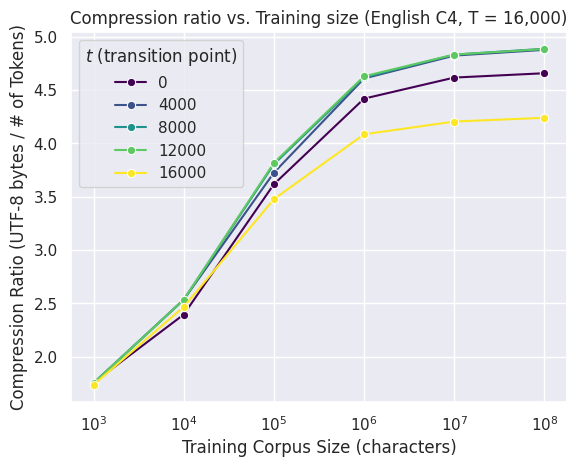

In [4]:
ax = sns.lineplot(
    data=df,
    x="train_chars",
    y="compression_ratio",
    hue="t",
    marker="o",
    palette="viridis",
)

ax.set(
    xscale="log",
    xlabel="Training Corpus Size (characters)",
    ylabel="Compression Ratio (UTF-8 bytes / # of Tokens)",
    title="Compression ratio vs. Training size (English C4, T = 16,000)",
)
ax.legend(title="$t$ (transition point)")

#### 3. Figure 4: k-gram Entropy vs Training Size

Reproduces Fig. 4 of Erdogan et al. (2026)

4a

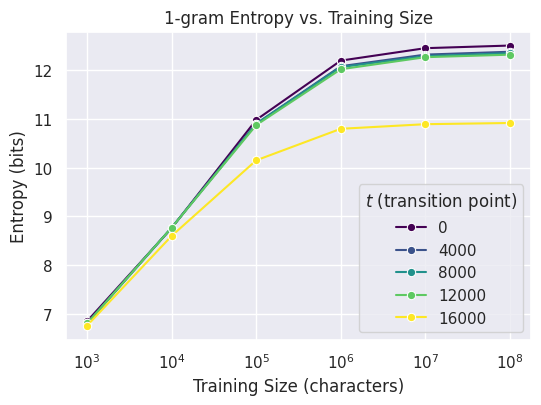

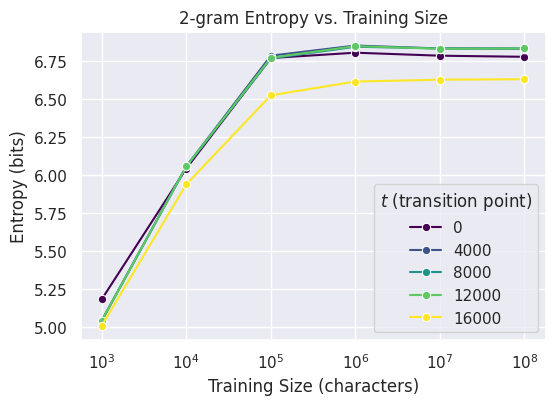

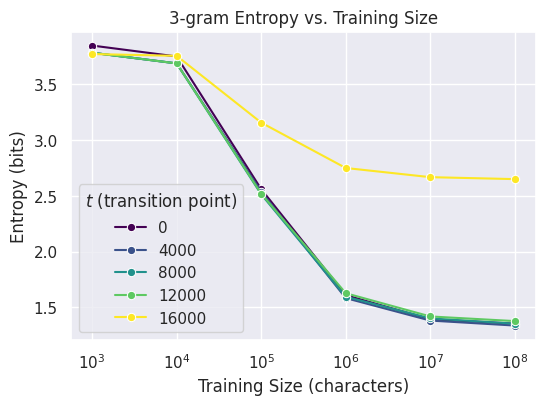

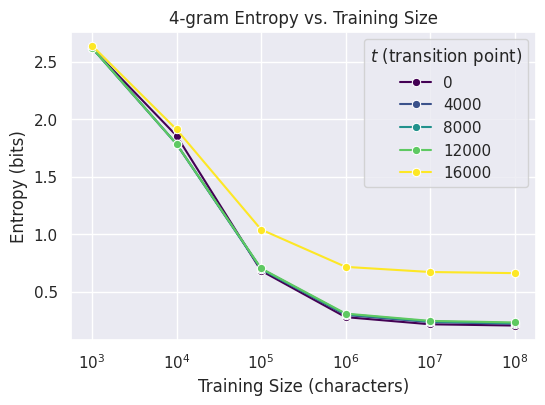

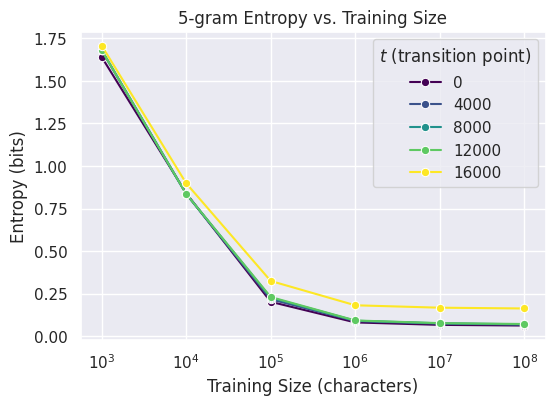

In [20]:
ks = [1, 2, 3, 4, 5]

for k in ks:
    plt.figure(figsize=(6, 4))
    ax = sns.lineplot(
        data=df,
        x="train_chars",
        y=f"H_{k}",
        hue="t",
        marker="o",
        palette="viridis",
    )
    ax.set(
        xscale="log",
        xlabel="Training Size (characters)",
        ylabel="Entropy (bits)",
        title=f"{k}-gram Entropy vs. Training Size",
    )
    ax.legend(title="$t$ (transition point)")
    plt.show()

4b

In [ ]:
# Need token count for each training corpus
# Entropy rate = H_k * tokens / train_chars

#### 4. Figure 8: Capacity Utilization vs Training Size

Reproduces Fig. 8 of Erdogan et al. (2026)

<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_235187/216282250.py:36: SyntaxWarning: invalid escape sequence '\e'
  extended_labels = labels + ["Metric Type:"] + ["Shannon ($\eta$)", "Renyi ($\eta_2$)"]
/tmp/ipykernel_235187/216282250.py:36: SyntaxWarning: invalid escape sequence '\e'
  extended_labels = labels + ["Metric Type:"] + ["Shannon ($\eta$)", "Renyi ($\eta_2$)"]


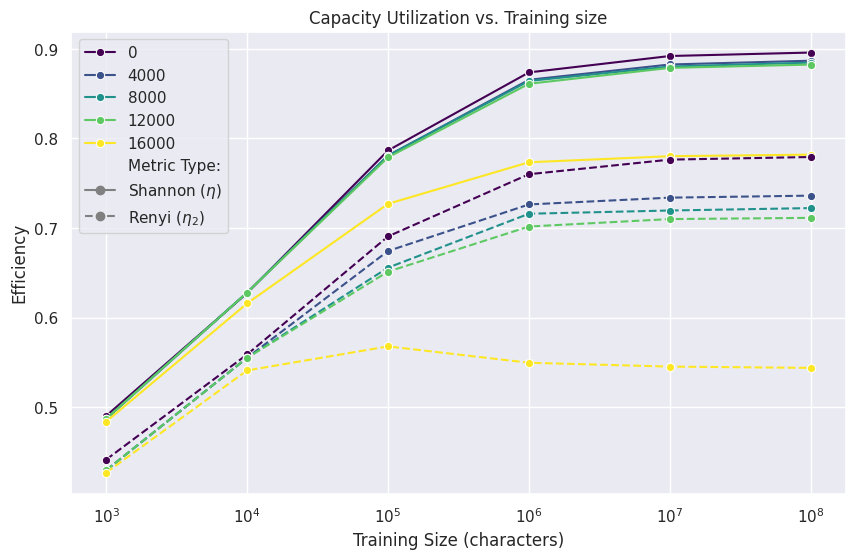

In [19]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df,
    x="train_chars",
    y="eta",
    hue="t",
    marker="o",
    palette="viridis",
    linestyle="-",
)
sns.lineplot(
    data=df,
    x="train_chars",
    y="eta_2",
    hue="t",
    marker="o",
    palette="viridis",
    linestyle="--",
    legend=False,
    ax=ax,
)
ax.set(
    xscale="log",
    xlabel="Training Size (characters)",
    ylabel="Efficiency",
    title="Capacity Utilization vs. Training size",
)
handles, labels = ax.get_legend_handles_labels()
shannon_line = mlines.Line2D(
    [], [], color="gray", linestyle="-", marker="o", label="Shannon"
)
renyi_line = mlines.Line2D(
    [], [], color="gray", linestyle="--", marker="o", label="Renyi"
)
extended_handles = handles + [mlines.Line2D([], [], linestyle="")] + [shannon_line, renyi_line]
extended_labels = labels + ["Metric Type:"] + ["Shannon ($\eta$)", "Renyi ($\eta_2$)"]
ax.legend(handles=extended_handles, labels=extended_labels)